In [5]:
# We use uv for faster installation
!pip install uv
!uv pip install -q autogluon.timeseries --system
!uv pip uninstall -q torchaudio torchvision torchtext --system # fix incompatible package versions on Colab

### Preparing the data for AutoGluon

In [6]:
import pandas as pd

url = "https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTh1.csv"
df = pd.read_csv(url)
df.head()

,date,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
0,2016-07-01 00:00:00,5.827,2.009,1.599,0.462,4.203,1.340,30.531000
1,2016-07-01 01:00:00,5.693,2.076,1.492,0.426,4.142,1.371,27.787001
2,2016-07-01 02:00:00,5.157,1.741,1.279,0.355,3.777,1.218,27.787001
3,2016-07-01 03:00:00,5.090,1.942,1.279,0.391,3.807,1.279,25.044001
4,2016-07-01 04:00:00,5.358,1.942,1.492,0.462,3.868,1.279,21.948000


In [7]:
df = df.rename(columns={"date": "timestamp"})
df["item_id"] = "ETTh1"
df = df[["item_id", "timestamp", "OT"]]
df = df.rename(columns={"OT": "target"})
df.head()

,item_id,timestamp,target
0,ETTh1,2016-07-01 00:00:00,30.531000
1,ETTh1,2016-07-01 01:00:00,27.787001
2,ETTh1,2016-07-01 02:00:00,27.787001
3,ETTh1,2016-07-01 03:00:00,25.044001
4,ETTh1,2016-07-01 04:00:00,21.948000


In [8]:
import pandas as pd
from autogluon.timeseries import TimeSeriesDataFrame, TimeSeriesPredictor

In [9]:
from autogluon.timeseries import TimeSeriesDataFrame

data = TimeSeriesDataFrame.from_data_frame(
    df,
    id_column="item_id",
    timestamp_column="timestamp",
)

data.head()

target
item_id timestamp                     
ETTh1   2016-07-01 00:00:00  30.531000
        2016-07-01 01:00:00  27.787001
        2016-07-01 02:00:00  27.787001
        2016-07-01 03:00:00  25.044001
        2016-07-01 04:00:00  21.948000

### Zero Shot Inferencing

In [10]:
num_test_windows = 3
prediction_length = 48
train_data, test_data = data.train_test_split(num_test_windows * prediction_length)

predictor = TimeSeriesPredictor(prediction_length=prediction_length).fit(
    train_data,
    presets="chronos2",
)

Beginning AutoGluon training...
AutoGluon will save models to '/content/AutogluonModels/ag-20260731_215646'
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Thu Apr 30 18:17:14 UTC 2026
CPU Count:          2
Pytorch Version:    2.9.1+cu128
CUDA Version:       12.8
GPU Memory:         GPU 0: 14.56/14.56 GB
Total GPU Memory:   Free: 14.56 GB, Allocated: 0.00 GB, Total: 14.56 GB
GPU Count:          1
Memory Avail:       11.22 GB / 12.67 GB (88.5%)
Disk Space Avail:   60.88 GB / 112.64 GB (54.1%)
Setting presets to: chronos2

Fitting with arguments:
{'enable_ensemble': True,
 'eval_metric': WQL,
 'hyperparameters': {'Chronos2': {'model_path': 'autogluon/chronos-2'}},
 'known_covariates_names': [],
 'num_val_windows': 1,
 'prediction_length': 48,
 'quantile_levels': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
 'random_seed': 123,
 'refit_every_n_windows

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/478M [00:00<?, ?B/s]

	22.58   s     = Training runtime
Training complete. Models trained: ['Chronos2']
Total runtime: 22.59 s
Best model: Chronos2


In [11]:
predictions = predictor.predict(train_data)
predictions.head()

Model not specified in predict, will default to the model with the best validation score: Chronos2


mean       0.1       0.2       0.3       0.4  \
item_id timestamp                                                               
ETTh1   2018-06-20 20:00:00  9.161201  8.651166  8.841279  8.960352  9.067863   
        2018-06-20 21:00:00  9.101426  8.461394  8.719458  8.875144  8.997653   
        2018-06-20 22:00:00  9.005819  8.187587  8.519009  8.720065  8.872996   
        2018-06-20 23:00:00  8.901584  7.911628  8.325464  8.575745  8.752024   
        2018-06-21 00:00:00  8.823861  7.683625  8.146255  8.427160  8.640375   

                                  0.5       0.6       0.7       0.8       0.9  
item_id timestamp                                                              
ETTh1   2018-06-20 20:00:00  9.161201  9.261539  9.349256  9.460671  9.619473  
        2018-06-20 21:00:00  9.101426  9.202594  9.308363  9.448168  9.679339  
        2018-06-20 22:00:00  9.005819  9.139740  9.275917  9.445936  9.704990  
        2018-06-20 23:00:00  8.901584  9.045297  9.200500  9.391203  9.674191  
        2018-06-21 00:00:00  8.823861  8.999486  9.171989  9.385458  9.702838

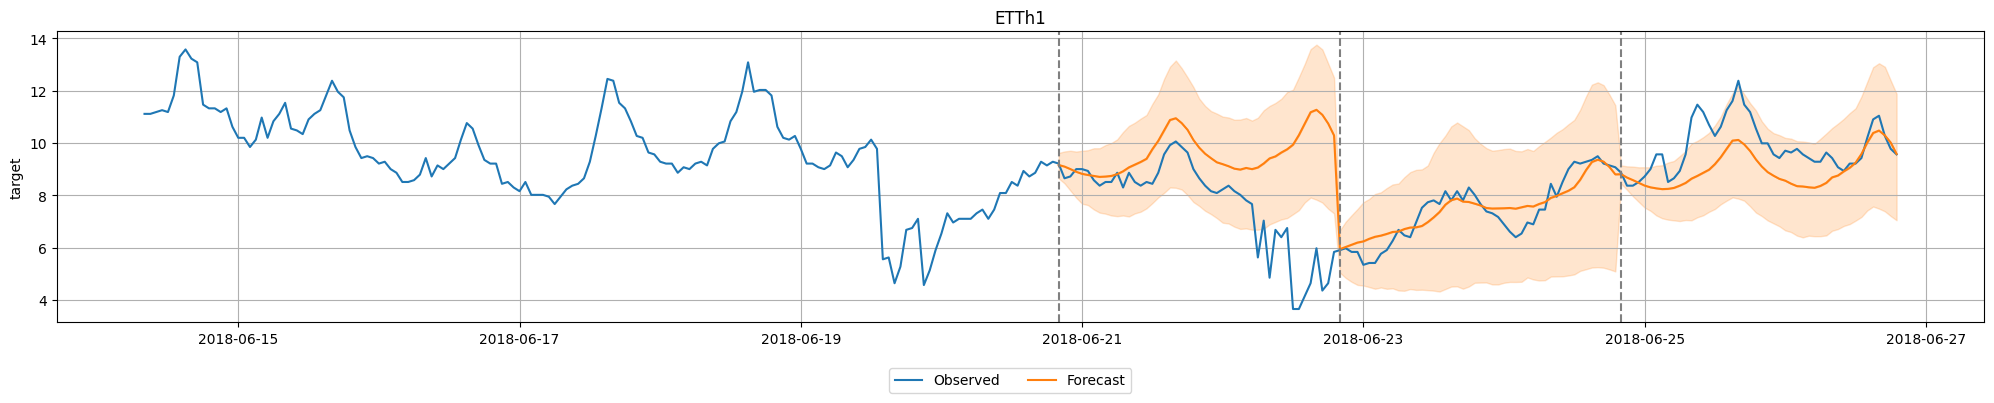

In [12]:
import matplotlib.pyplot as plt

# Generate predictions for multiple windows
predictions_per_window = predictor.backtest_predictions(test_data, num_val_windows=num_test_windows)

# Plot predictions for the first two time series
item_ids = test_data.item_ids[:2].tolist()
all_predictions = pd.concat(predictions_per_window)
predictor.plot(test_data, all_predictions, max_history_length=300, item_ids=item_ids)

# Optional: Plot the cutoff dates with dashed vertical lines
for cutoff in range(-num_test_windows * prediction_length, 0, prediction_length):
    for i, ax in enumerate(plt.gcf().axes):
        cutoff_timestamp = test_data.loc[item_ids[i]].index[cutoff]
        ax.axvline(cutoff_timestamp, color='gray', linestyle='--')
plt.show()

In [13]:
predictor.leaderboard(test_data)

Additional data provided, testing on additional data. Resulting leaderboard will be sorted according to test score (`score_test`).


,model,score_test,score_val,pred_time_test,pred_time_val,fit_time_marginal,fit_order
0,Chronos2,-0.073507,None,0.548997,None,22.579105,1


## Forecasting with covariates

In [14]:
data = TimeSeriesDataFrame.from_path(
    "https://autogluon.s3.amazonaws.com/datasets/timeseries/bull/test.parquet", id_column="id"
)
data.head()

load  airtemperature  \
item_id                timestamp                                     
Bull_education_Magaret 2016-01-01 00:00:00  0.0000             9.4   
                       2016-01-01 01:00:00  2.7908             8.9   
                       2016-01-01 02:00:00  3.7210             8.9   
                       2016-01-01 03:00:00  2.7908             8.3   
                       2016-01-01 04:00:00  9.3025             7.8   

                                            dewtemperature  sealvlpressure  
item_id                timestamp                                            
Bull_education_Magaret 2016-01-01 00:00:00             3.3     1028.699951  
                       2016-01-01 01:00:00             2.2     1028.800049  
                       2016-01-01 02:00:00             2.2     1029.599976  
                       2016-01-01 03:00:00             1.7     1029.500000  
                       2016-01-01 04:00:00             1.7     1029.599976

In [15]:
prediction_length = 24
train_data, test_data = data.train_test_split(prediction_length=prediction_length)

Sorting the dataframe index before generating the train/test split.


In [16]:
predictor = TimeSeriesPredictor(
    prediction_length=prediction_length,
    target="load",
    known_covariates_names=["airtemperature", "dewtemperature", "sealvlpressure"],
    eval_metric="MASE",
).fit(
    train_data,
    hyperparameters={"Chronos": {}, "Chronos2": {}},
    enable_ensemble=False,
    time_limit=60,
)

Beginning AutoGluon training... Time limit = 60s
AutoGluon will save models to '/content/AutogluonModels/ag-20260731_215724'
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Thu Apr 30 18:17:14 UTC 2026
CPU Count:          2
Pytorch Version:    2.9.1+cu128
CUDA Version:       12.8
GPU Memory:         GPU 0: 14.55/14.56 GB
Total GPU Memory:   Free: 14.55 GB, Allocated: 0.01 GB, Total: 14.56 GB
GPU Count:          1
Memory Avail:       10.04 GB / 12.67 GB (79.3%)
Disk Space Avail:   60.40 GB / 112.64 GB (53.6%)

Fitting with arguments:
{'enable_ensemble': False,
 'eval_metric': MASE,
 'hyperparameters': {'Chronos': {}, 'Chronos2': {}},
 'known_covariates_names': ['airtemperature',
                            'dewtemperature',
                            'sealvlpressure'],
 'num_val_windows': 1,
 'prediction_length': 24,
 'quantile_levels': [0.1, 0.2, 0.

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/191M [00:00<?, ?B/s]

	-1.0865       = Validation score (-MASE)
	2.86    s     = Training runtime
	3.02    s     = Validation (prediction) runtime
Training complete. Models trained: ['Chronos2', 'Chronos[autogluon__chronos-bolt-small]']
Total runtime: 13.65 s
Best model: Chronos2
Best model score: -0.8172


In [17]:
predictor.leaderboard(test_data)

Additional data provided, testing on additional data. Resulting leaderboard will be sorted according to test score (`score_test`).


,model,score_test,score_val,pred_time_test,pred_time_val,fit_time_marginal,fit_order
0,Chronos2,-0.696239,-0.817203,8.209312,6.837736,0.873646,1
1,Chronos[autogluon__chronos-bolt-small],-1.278404,-1.086471,0.480727,3.023088,2.857111,2


In [19]:
predictor.feature_importance(test_data, model="Chronos2", relative_scores=True)

Computing feature importance


,importance,stdev,n,p99_low,p99_high
airtemperature,0.324308,0.000000e+00,5.0,0.324308,0.324308
dewtemperature,0.057110,7.757919e-18,5.0,0.057110,0.057110
sealvlpressure,0.038278,0.000000e+00,5.0,0.038278,0.038278


## Fine Tuning the Model

In [20]:
predictor = TimeSeriesPredictor(
    prediction_length=prediction_length,
    target="load",
    known_covariates_names=["airtemperature", "dewtemperature", "sealvlpressure"],
    eval_metric="MASE",
).fit(
    train_data=train_data,
    hyperparameters={
        "Chronos2": [
            # Zero-shot model
            {"fine_tune": False, "ag_args": {"name_suffix": "ZeroShot"}},
            # Fine-tuned model
            {"fine_tune": True, "ag_args": {"name_suffix": "FineTuned"}},
        ]
    },
    time_limit=300,  # time limit in seconds
    enable_ensemble=False,
)

Beginning AutoGluon training... Time limit = 300s
AutoGluon will save models to '/content/AutogluonModels/ag-20260731_221328'
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Thu Apr 30 18:17:14 UTC 2026
CPU Count:          2
Pytorch Version:    2.9.1+cu128
CUDA Version:       12.8
GPU Memory:         GPU 0: 14.55/14.56 GB
Total GPU Memory:   Free: 14.55 GB, Allocated: 0.01 GB, Total: 14.56 GB
GPU Count:          1
Memory Avail:       9.73 GB / 12.67 GB (76.8%)
Disk Space Avail:   60.19 GB / 112.64 GB (53.4%)

Fitting with arguments:
{'enable_ensemble': False,
 'eval_metric': MASE,
 'hyperparameters': {'Chronos2': [{'ag_args': {'name_suffix': 'ZeroShot'},
                                   'fine_tune': False},
                                  {'ag_args': {'name_suffix': 'FineTuned'},
                                   'fine_tune': True}]},
 'known_co

In [21]:
predictor.leaderboard(test_data)

Additional data provided, testing on additional data. Resulting leaderboard will be sorted according to test score (`score_test`).


,model,score_test,score_val,pred_time_test,pred_time_val,fit_time_marginal,fit_order
0,Chronos2FineTuned,-0.691076,-0.813391,8.483005,9.293487,268.917413,2
1,Chronos2ZeroShot,-0.696239,-0.817203,8.297505,7.057329,0.811243,1


### Interpretation

The MASE is further decreased with the fine tuning